<a href="https://colab.research.google.com/github/AIDE-00001/Portafolio/blob/main/optimizaci%C3%B3n_aeroportuaria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**CLASE 1**

In [ ]:
import pandas as pd

datos =  pd.read_csv('/content/flights.csv')
datos.shape

In [ ]:
datos.head()

In [ ]:
datos.info()

In [ ]:
datos.describe()
#para ver la descripcion de estadistica

In [ ]:
#para ver las variables categoricas se debe poner(include='O')
datos.describe(include='O')

In [ ]:
#Bibliotecas para poder graficar y visualizar nuestros datos
import seaborn as sns
import matplotlib.pyplot as plt
#para ver el promedio=agrupar por aerolinea[variable respuesta]funcion asociada promedio.como queremos dejar como un a columna .reset_index
avg_delay = datos.groupby('airline')['delay'].mean().reset_index()
#grafico de barra(x,y,conjuto de datos)
sns.barplot(x='airline',y='delay',data=avg_delay)
#titulo
plt.title('Compañías aéreas vs atraso promedio')
#etiquetas de cada uno de los ejes:
plt.xlabel('Compañía aérea')
plt.ylabel('Atraso promedio en minutos')
#para hacer el grafico
plt.show()

#grafico para ver el numeroo de vuelos
sns.countplot(data=datos, x='airline')
plt.title('Número de vuelos por Compañía aérea')
plt.xlabel('Compañía aérea')
plt.ylabel('Número de vuelos')
plt.show()

In [ ]:
#genrar mas graficos
#cantidad de atraso promedio si es schegen o no
avg_delay = datos.groupby('schengen')['delay'].mean().reset_index()
sns.barplot(x='schengen',y='delay',data=avg_delay)
plt.title('Tipo de vuelo vs atraso promedio')
plt.xlabel('Tipo de vuelo')
plt.ylabel('Atraso promedio en minutos')
plt.show()
#para el conteo
sns.countplot(data=datos, x='schengen')
plt.title('Número de vuelos por Tipo')
plt.xlabel('Tipo de Vuelo')
plt.ylabel('Número de vuelos')
plt.show()

In [ ]:
#ver si estos atraso ocurren en dias feriados
avg_delay = datos.groupby('is_holiday')['delay'].mean().reset_index()
sns.barplot(x='is_holiday',y='delay',data=avg_delay)
plt.title('Días feriados vs atraso promedio')
plt.xlabel('Días feriados')
plt.ylabel('Atraso promedio en minutos')
plt.show()

In [ ]:
#nos devuelve un indice que mas tiene de mayor a menor
datos['aircraft_type'].value_counts().index

In [ ]:
#vamos a colocar un order
order = datos['aircraft_type'].value_counts().index
sns.countplot(data=datos, x='aircraft_type',order=order)
plt.title('Número de vuelos por Tipo de aeronave')
plt.xticks(rotation=70)
plt.xlabel('Tipo de Aeronave')
plt.ylabel('Número de vuelos')
plt.show()

In [ ]:

sns.histplot(data=datos,x='arrival_time',kde=True)

https://en.wikipedia.org/wiki/Freedman%E2%80%93Diaconis_rule

In [ ]:
#regla de Fredman
sns.histplot(data=datos,x='arrival_time',kde=True,bins=10)

In [ ]:
#nos ayuda a restar el rango itercuantil para la regla de Freedamn
import numpy as np

def ancho_bin(df,columna):
  q75,q25 = np.percentile(df[columna],[75,25])
  iqr = q75-q25
  ancho = 2 * iqr * np.power(len(df[columna]), -1/3)
  return ancho

In [ ]:
#crear una variable
binwidth = ancho_bin(datos,'arrival_time')
sns.histplot(data=datos,x='arrival_time',kde=True,binwidth=binwidth)

In [ ]:
#hacerlo para el hoario de salida
binwidth = ancho_bin(datos,'departure_time')
sns.histplot(data=datos,x='departure_time',kde=True,binwidth=binwidth)

In [ ]:
#retrasos de lo vuelos
#generar valiables:
atraso_promedio = datos['delay'].mean()
atraso_mediana = datos['delay'].median()

#generar los graficos con los valores anterioes
fig, ax = plt.subplots(1,2,figsize=(9,4))

#crear un boxplot
sns.boxplot(data=datos, y='delay',ax=ax[0])
ax[0].set_title('Boxplot')
ax[0].axhline(y=atraso_promedio, color='r', linestyle='--', label='Promedio')
ax[0].legend()

#establecer el biwidht
binwidth = ancho_bin(datos, 'delay')
#crear el histograma
sns.histplot(data=datos, x='delay', ax=ax[1], kde=True, binwidth=binwidth)
plt.ylabel('Número de vuelos')
plt.grid(False)
ax[1].set_title('Histograma')
ax[1].axvline(x=atraso_promedio, color='r', linestyle='--', label='Promedio')
ax[1].axvline(x=atraso_mediana, color='y', linestyle='--', label='Mediana')
ax[1].legend()

#para que los graficos so se solapen
plt.tight_layout()

plt.show()

#**CLASE 2**

In [ ]:
#vamos a ver las columnas
datos.columns

In [ ]:
#podemos crear una columna llamada datos
#vamos a tomar el año y convertilo en string y vamos a concatenarlo con - y con el dia como cominza en dia 0 sumamos+1.astype(str)
datos['date'] = datos['year'].astype(str) +'-'+(datos['day']+1).astype(str)
#convertimos en formato fecha
datos['date'] = pd.to_datetime(datos['date'],format='%Y-%j')
#vemos las 2 filas del final
datos.tail(2)

In [ ]:
#generamos una columna para ver si es fin de semna o no
#weeday.isin(si el dia de la semana esta entre 5 y 6 dia)
datos['is_weekend'] = datos['date'].dt.weekday.isin([5,6])
#.dt.day_name() nos devuelve el dia de la semana
datos['day_name'] = datos['date'].dt.day_name()
#muestra de 5 registros
datos.sample(5)

In [ ]:
#Ver que tipo de columnas tenemos
datos.info()

In [ ]:
#para ignorar advertencias
import warnings

warnings.filterwarnings('ignore')

In [ ]:
#tomar las mismas columnas y reemplazar a traves del diccionario
datos['schengen'] = datos['schengen'].replace({'non-schengen':0,'schengen':1})
#para las que son booleanas
datos['is_holiday'] = datos['is_holiday'].replace({False:0,True:1})
datos['is_weekend'] = datos['is_weekend'].replace({False:0,True:1})
#ver 3 filas al azar
datos.sample(3)

In [ ]:
#crear una variable que llamaremos  categoricas y hacemos una lista de columnas que vamos a cambiar
categoricas = ['airline','aircraft_type','origin','day_name']

# nos permite codificar en 0 y 1 (datos,columnas=categoricas,tipo entero)mostrar las primeras 5 filas
pd.get_dummies(data=datos,columns=categoricas, dtype=int).head()

In [ ]:
#guardamos nuestros datos codificados
datos_codificados =pd.get_dummies(data=datos,columns=categoricas, dtype=int)
#visualizamos y
datos_codificados.sample(5)

In [ ]:
#las variables muy semejantes pueden en ocasiones perjudicar nuestro análisis
#ver las correlaciones un mapa de corr nos dice como se correlaciona va de  a -1 y son directamente proporcionales
#'arrival_time ' y 'deparmet_time' existe una correlacion de casi 100% por lo que puede sesgar mi modelo
datos[['arrival_time','departure_time']].corr()

In [ ]:
#ver la varibles que creamos para ver cuale ssi necesitamos y cuales no
datos_codificados.info()

In [ ]:
#vamos a eliminar la columas de la siguente lista
df = datos_codificados.drop(columns=['flight_id','departure_time','day','year','date'])
#ver 10 filas al azar
df.sample(10)

#**CLASE 3**

https://scikit-learn.org/stable/

In [ ]:
# bibliote skelarn para trabajar con machine learning
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split

#variables independientes
X = df.drop(['delay'],axis=1)
#variable dependiente
y = df['delay']

#segregar el modelo
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

#crear el modelo
baseline = DummyRegressor()
#aajustar los datos al modelo
baseline.fit(X_train,y_train)

In [ ]:
#vamos a evaluarlo con metricas
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#hacemos la prediccion
y_pred_dummy = baseline.predict(X_test)

#Crear la funcion
def calcular_regresion(y_test,y_pred):
  rmse = mean_squared_error(y_test,y_pred)
  mae= mean_absolute_error(y_test,y_pred)
  r2 = r2_score(y_test,y_pred)
  #crear diccionario de metricas
  metricas = {
      #roundud((),nos devuelve 4 decimales)
      'RMSE':round(rmse**(1/2),4),
      'MAE': round(mae,4),
      'R2': round(r2,4)
  }
  #devolver las metricas
  return metricas

In [ ]:
#calcular la regresion
resultados_baseline = calcular_regresion(y_test, y_pred_dummy)
#visualizamos
resultados_baseline

In [ ]:
# para poder realizar bosques aleatorios
from sklearn.ensemble import RandomForestRegressor

#crear el modelo(parametro ajustado=profundidad,estado de aletoriedad=5)
modelo = RandomForestRegressor(max_depth=5, random_state=42)
#hacer el auste de los datos
modelo.fit(X_train,y_train)
#prediccion
ypred = modelo.predict(X_test)
#vcalcular regresion
resultados_rf = calcular_regresion(y_test,ypred)
#visualizamos
resultados_rf

#va encontrar el mejor combinacion al crear muchos arboles de decision

In [ ]:
#para ver graficamente como esta nuestro modelo
from yellowbrick.regressor import prediction_error

#visualizar la prediccion del error
visualizer = prediction_error(modelo, X_train, y_train, X_test, y_test);

In [ ]:
#plot para ver los residuos
from yellowbrick.regressor import residuals_plot

viz = residuals_plot(modelo, X_train, y_train, X_test, y_test);

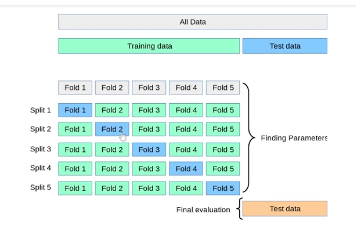

In [ ]:
#tiene todo el counto de datos y 80% para entrenamiento y el 20% ppara prueba

from sklearn.model_selection import KFold, cross_validate

#definir el scoring(debemos usar una funcion de utildad aqui queremos maximizar el error solo el r^2 segura siendo el mismo
scoring = {
    'RMSE':'neg_root_mean_squared_error',
    'MAE':'neg_mean_absolute_error',
    'R2':'r2'
}
#que haga todas las combinaciones posibles,tenga la misma semilla
cv = KFold(n_splits=5,shuffle=True, random_state=42)
#validacion cruzada(estimador,x,y,scorining,validacion cruzada)
cv_results = cross_validate(modelo, X_train, y_train, scoring=scoring, cv=cv)
cv_results

#**CLASE 4**

In [ ]:
#ver los atributos que estamos tomandos
len(df.columns)

In [ ]:
#vamos a ver el porcentaje de importancia de cada fechure

importances = modelo.feature_importances_

In [ ]:
#Vamos a colocar un diccionariopara ver la imortancia de nuestros fechures
feature_importances = pd.DataFrame({'Features':X.columns,'Importances':(importances*100).round(2)}).sort_values('Importances',ascending=False)
feature_importances

Vemos que hay varios atributos que no representan casi nada en nuestro modelo

In [94]:
#crear un data frame que tenga los indices que van hacer las metricas
resultados = pd.DataFrame(index=['RMSE','MAE','R2'])
#hacer nuestro regresor donde colocaremos diversos feachures
model_features = RandomForestRegressor(max_depth=5,random_state=42)
#la lista de iteracion que es la cantidad de features(comenzar en 1,hasta 35,de pasos de 5)
ct_features = [i if i != 0 else 1 for i in range(0,35,5)]

#vamos a iterar
for i in ct_features:
  #todos los valores hasta i de 'feactures
  selected_features = feature_importances['Features'].values[:i]
  #de las variables seleccionadas entrenamos
  X_train_sel = X_train[selected_features]
  X_test_sel = X_test[selected_features]
  #tomamos el modelo y hacemos el fit
  model_features.fit(X_train_sel, y_train)
  #vamos hacer la prediccion
  y_pred = model_features.predict(X_test_sel)
  #las metricas
  metricas = calcular_regresion(y_test,y_pred)
  #data frame resultados
  resultados[i] = list(metricas.values())

#visualizamos
resultados




KeyError: "['aircraft_type_Boeing 737', 'origin_ZQO'] not in index"

Vemos que nuestro r2 despues de 15 features ya no hace ninguna diferencia seguir agregandolos

In [ ]:
#vomos hacer el rango de 10 a 15 ya que la ultima mejora esta entre 10 y 15
resultados = pd.DataFrame(index=['RMSE','MAE','R2'])
model_features = RandomForestRegressor(max_depth=5,random_state=42)
ct_features = range(10,16)

for i in ct_features:
  selected_features = feature_importances['Features'].values[:i]
  X_train_sel = X_train[selected_features]
  X_test_sel = X_test[selected_features]
  model_features.fit(X_train_sel, y_train)
  y_pred = model_features.predict(X_test_sel)
  metricas = calcular_regresion(y_test,y_pred)
  resultados[i] = list(metricas.values())

resultados

Notamos que a partir de 12 features ya no hay una mejora, por lo podemos dejar unicamente en 13 features

In [ ]:
#features seleccionadas hasta 13
selected_features = feature_importances['Features'].values[:13]
X_selected_features = X[selected_features]
X_selected_features

In [ ]:
#Hacer la division
X_train,X_test,y_train,y_test = train_test_split(X_selected_features,y,random_state=42)

In [ ]:
#Vamos a ajustar nuestros hiperparametros
param_grid = {
              'max_depth':[5,10,15],
              'min_samples_leaf':[1,2,3],
              'min_samples_split':[2,4,6],
              'n_estimators':[100,150,200]
             }

In [89]:
#busqueda del mejor estimador
from sklearn.model_selection import GridSearchCV

#tomar la validacion cruzada especificar 5 divisiones, que se mescle,estado de aleatoriedad=42
cv = KFold(n_splits=5, shuffle=True, random_state=42)
#donde vamos a probar nuestros parametros
model_grid = GridSearchCV(RandomForestRegressor(random_state=42),
                          param_grid=param_grid, scoring='r2',
                          cv=cv)

model_grid.fit(X_train,y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [5, 10, 15],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 4, 6],
                         'n_estimators': [100, 150, 200]},
             scoring='r2')

In [95]:
#para saber cual es nuestro mejor etsimador
model_grid.best_params_

{'max_depth': 10,
 'min_samples_leaf': 3,
 'min_samples_split': 2,
 'n_estimators': 200}

In [96]:
#vamos a ver como predijo
y_pred_grid = model_grid.predict(X_test)
metricas_model_grid = calcular_regresion(y_test,y_pred_grid)
metricas_model_grid

{'RMSE': 13.2308, 'MAE': 10.6296, 'R2': 0.6754}

In [97]:
#lista de los valores delmodelo grid
resultados['modelo_grid'] = list(metricas_model_grid.values())
resultados

,1,5,10,modelo_grid
RMSE,18.8639,15.1651,13.7426,13.2308
MAE,14.9854,12.0714,11.0282,10.6296
R2,0.3402,0.5736,0.6498,0.6754


In [98]:
#modelo para serializar con ayuda de pickle
import pickle

try:
  with open('champion.pkl','wb') as file:
    pickle.dump(model_grid.best_estimator_,file)
  print('Modelo serializado con éxito')
except Exception as e:
  print('Se presentó un error al almacenar el modelo: ',str(e))

Modelo serializado con éxito
